# panelib Showcase

This notebook celebrates the full functionality of **panelib** — a panel causal inference library
implementing DiD, three flavors of Synthetic Control, and Synthetic DiD.

We simulate a single treated unit against 30 controls under a factor-model DGP:
$$Y_{it} = \alpha_i + 0.3t + \lambda_i F_t + \varepsilon_{it}$$

- **Scenario 1** (σ_λ = 0): parallel trends holds — all methods should recover the ATT
- **Scenario 2** (σ_λ = 1): parallel trends violated — DiD will be biased; factor-robust methods fare better

| Figure | Content |
|--------|---------|
| **Figure 0** | Overlay: SC-CL, DiD, SDID counterfactuals on the same axes (both scenarios) |
| **Figure 1** | All 5 estimators — Scenario 1 (PT holds) |
| **Figure 2** | All 5 estimators — Scenario 2 (PT violated) |
| **Figure 3** | DiD Event Study — pre-trend parallel trends test |
| **Figure 4** | Control weights: SC-ADH ω and SDID ω + λ |
| **Figure 5** | Bias summary bar chart: ATT estimate − true ATT |

| Model | CI Method |
|-------|-----------|
| SC-ADH, SC-DI, SC-CL | Time-block conformal permutation |
| DiD (TWFE) | Time-block conformal (CWZ 2021) |
| SDID | Time-block conformal (CWZ 2021) |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

_nb_dir = os.getcwd()
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from IPython.display import display
from panelib import did, sc, sdid, dgp
print('panelib loaded successfully.')

panelib loaded successfully.


In [2]:
# ── DGP parameters ─────────────────────────────────────────────────────────
SEED     = 42
T_PRE    = 10    # pre-treatment periods
T_POST   = 5     # post-treatment periods
N_CTRL   = 30    # control units
NOISE_SD = 0.1   # idiosyncratic noise σ_ε (marginal std)
AR_COEF  = 0.7   # AR(1) coefficient for idiosyncratic shocks
ATT_PCT  = 0.15  # treatment effect as % of Y_treat at onset (~15%)

DATA_DICT = {'treatment': 'treated', 'date': 'time',
             'post': 'post', 'unitid': 'unit_id', 'outcome': 'y'}

# Scenario 1: parallel trends  (σ_λ = 0)
df0, att0 = dgp.simulate_panel(
    seed=SEED, T_pre=T_PRE, T_post=T_POST, N_control=N_CTRL,
    sigma_lambda=0.0, noise_sd=NOISE_SD, att_pct=ATT_PCT, ar_coef=AR_COEF)

# Scenario 2: factor model / PT violated  (σ_λ = 1)
df1, att1 = dgp.simulate_panel(
    seed=SEED, T_pre=T_PRE, T_post=T_POST, N_control=N_CTRL,
    sigma_lambda=1.0, noise_sd=NOISE_SD, att_pct=ATT_PCT, ar_coef=AR_COEF)

print(f'Scenario 1  (σ_λ=0, PT holds):     True ATT = {att0:.4f}')
print(f'Scenario 2  (σ_λ=1, PT violated):  True ATT = {att1:.4f}')
print(f'N_ctrl={N_CTRL}, T_pre={T_PRE}, T_post={T_POST}, '
      f'noise={NOISE_SD}, ar={AR_COEF}, att_pct={ATT_PCT:.0%}')

Scenario 1  (σ_λ=0, PT holds):     True ATT = 1.3487
Scenario 2  (σ_λ=1, PT violated):  True ATT = 1.3388
N_ctrl=30, T_pre=10, T_post=5, noise=0.1, ar=0.7, att_pct=15%


In [3]:
# ── Fit all five estimators — Scenario 1 (σ_λ = 0) ────────────────────────
print('=' * 60)
print('  Scenario 1: Parallel Trends Holds  (σ_λ = 0)')
print('=' * 60)
t_start = time.time()

print('\n[1/5] SC-ADH  (Abadie-Diamond-Hainmueller)')
r0_adh = sc.sc_model(model_name='adh', data=df0, data_dict=DATA_DICT)
print(f'  ATT = {r0_adh["results_df"]["atet"].iloc[0]:.4f}  '
      f'(true: {att0:.4f})  '
      f'CI = ({r0_adh["results_df"]["ci_lower"].iloc[0]:.4f}, '
      f'{r0_adh["results_df"]["ci_upper"].iloc[0]:.4f})')

print('\n[2/5] SC-DI  (Doudchenko-Imbens elastic-net)')
r0_di = sc.sc_model(model_name='di', data=df0, data_dict=DATA_DICT)
print(f'  ATT = {r0_di["results_df"]["atet"].iloc[0]:.4f}  '
      f'(true: {att0:.4f})  '
      f'CI = ({r0_di["results_df"]["ci_lower"].iloc[0]:.4f}, '
      f'{r0_di["results_df"]["ci_upper"].iloc[0]:.4f})')

print('\n[3/5] SC-CL  (Constrained Lasso)')
r0_cl = sc.sc_model(model_name='cl', data=df0, data_dict=DATA_DICT)
print(f'  ATT = {r0_cl["results_df"]["atet"].iloc[0]:.4f}  '
      f'(true: {att0:.4f})  '
      f'CI = ({r0_cl["results_df"]["ci_lower"].iloc[0]:.4f}, '
      f'{r0_cl["results_df"]["ci_upper"].iloc[0]:.4f})')

print('\n[4/5] DiD  (TWFE, CWZ conformal CI)')
r0_did    = did.twfe(data=df0, data_dict=DATA_DICT)
r0_did_cf = did.twfe_conformal(data=df0, data_dict=DATA_DICT)
_att = r0_did_cf['att']
print(f'  ATT = {_att:.4f}  '
      f'(true: {att0:.4f})  '
      f"CI = ({r0_did_cf['ci_lower']:.4f}, {r0_did_cf['ci_upper']:.4f})  "
      f"p = {r0_did_cf['pvalue']:.3f}")

print('\n[5/5] SDID  (Arkhangelsky et al. 2021) + conformal inference')
r0_sdid     = sdid.twfe_sdid(data=df0, data_dict=DATA_DICT)
r0_sdid_inf = sdid.sdid_conformal_inference(data=df0, data_dict=DATA_DICT)
_att = float(r0_sdid['sdid'].loc['post_SDiD', 'coef_'])
print(f'  ATT = {_att:.4f}  '
      f'(true: {att0:.4f})  '
      f'CI = ({r0_sdid_inf["ci_interval"][0]:.4f}, {r0_sdid_inf["ci_interval"][1]:.4f})  '
      f'p = {r0_sdid_inf["pvalue"]:.3f}')

print(f'\nScenario 1 elapsed: {time.time() - t_start:.0f}s')

  Scenario 1: Parallel Trends Holds  (σ_λ = 0)

[1/5] SC-ADH  (Abadie-Diamond-Hainmueller)
Using ADH
  ATT = 1.3036  (true: 1.3487)  CI = (nan, nan)

[2/5] SC-DI  (Doudchenko-Imbens elastic-net)
Using DI
  ATT = 1.4126  (true: 1.3487)  CI = (nan, nan)

[3/5] SC-CL  (Constrained Lasso)
Using CL
  ATT = 1.3204  (true: 1.3487)  CI = (nan, nan)

[4/5] DiD  (TWFE, CWZ conformal CI)
  ATT = 1.3771  (true: 1.3487)  CI = (1.2033, 1.6839)  p = 0.029

[5/5] SDID  (Arkhangelsky et al. 2021) + conformal inference
  ATT = 1.3473  (true: 1.3487)  CI = (1.2418, 1.4547)  p = 0.029

Scenario 1 elapsed: 78s


In [4]:
# ── Fit all five estimators — Scenario 2 (σ_λ = 1) ────────────────────────
print('=' * 60)
print('  Scenario 2: Parallel Trends Violated  (σ_λ = 1)')
print('=' * 60)
t_start = time.time()

print('\n[1/5] SC-ADH  (Abadie-Diamond-Hainmueller)')
r1_adh = sc.sc_model(model_name='adh', data=df1, data_dict=DATA_DICT)
print(f'  ATT = {r1_adh["results_df"]["atet"].iloc[0]:.4f}  '
      f'(true: {att1:.4f})  '
      f'CI = ({r1_adh["results_df"]["ci_lower"].iloc[0]:.4f}, '
      f'{r1_adh["results_df"]["ci_upper"].iloc[0]:.4f})')

print('\n[2/5] SC-DI  (Doudchenko-Imbens elastic-net)')
r1_di = sc.sc_model(model_name='di', data=df1, data_dict=DATA_DICT)
print(f'  ATT = {r1_di["results_df"]["atet"].iloc[0]:.4f}  '
      f'(true: {att1:.4f})  '
      f'CI = ({r1_di["results_df"]["ci_lower"].iloc[0]:.4f}, '
      f'{r1_di["results_df"]["ci_upper"].iloc[0]:.4f})')

print('\n[3/5] SC-CL  (Constrained Lasso)')
r1_cl = sc.sc_model(model_name='cl', data=df1, data_dict=DATA_DICT)
print(f'  ATT = {r1_cl["results_df"]["atet"].iloc[0]:.4f}  '
      f'(true: {att1:.4f})  '
      f'CI = ({r1_cl["results_df"]["ci_lower"].iloc[0]:.4f}, '
      f'{r1_cl["results_df"]["ci_upper"].iloc[0]:.4f})')

print('\n[4/5] DiD  (TWFE, CWZ conformal CI)')
r1_did    = did.twfe(data=df1, data_dict=DATA_DICT)
r1_did_cf = did.twfe_conformal(data=df1, data_dict=DATA_DICT)
_att = r1_did_cf['att']
print(f'  ATT = {_att:.4f}  '
      f'(true: {att1:.4f})  '
      f"CI = ({r1_did_cf['ci_lower']:.4f}, {r1_did_cf['ci_upper']:.4f})  "
      f"p = {r1_did_cf['pvalue']:.3f}")

print('\n[5/5] SDID  (Arkhangelsky et al. 2021) + conformal inference')
r1_sdid     = sdid.twfe_sdid(data=df1, data_dict=DATA_DICT)
r1_sdid_inf = sdid.sdid_conformal_inference(data=df1, data_dict=DATA_DICT)
_att = float(r1_sdid['sdid'].loc['post_SDiD', 'coef_'])
print(f'  ATT = {_att:.4f}  '
      f'(true: {att1:.4f})  '
      f'CI = ({r1_sdid_inf["ci_interval"][0]:.4f}, {r1_sdid_inf["ci_interval"][1]:.4f})  '
      f'p = {r1_sdid_inf["pvalue"]:.3f}')

print(f'\nScenario 2 elapsed: {time.time() - t_start:.0f}s')

  Scenario 2: Parallel Trends Violated  (σ_λ = 1)

[1/5] SC-ADH  (Abadie-Diamond-Hainmueller)
Using ADH
  ATT = 1.2993  (true: 1.3388)  CI = (0.0330, 3.2023)

[2/5] SC-DI  (Doudchenko-Imbens elastic-net)
Using DI
  ATT = 1.1676  (true: 1.3388)  CI = (nan, nan)

[3/5] SC-CL  (Constrained Lasso)
Using CL
  ATT = 1.3162  (true: 1.3388)  CI = (-0.1505, 3.1236)

[4/5] DiD  (TWFE, CWZ conformal CI)
  ATT = 0.8013  (true: 1.3388)  CI = (-10.4298, 9.7875)  p = 0.114

[5/5] SDID  (Arkhangelsky et al. 2021) + conformal inference
  ATT = 1.3721  (true: 1.3388)  CI = (0.0035, 3.2371)  p = 0.029

Scenario 2 elapsed: 33s


In [5]:
# ── Summary: ATT estimates, bias, CI, and pre-fit MAPE ──────────────────────

def make_summary(r_adh, r_di, r_cl, r_did_cf, r_sdid_res, r_sdid_inf, true_att):
    rows = []
    for name, res in [('SC-ADH', r_adh), ('SC-DI', r_di), ('SC-CL', r_cl)]:
        rd    = res['results_df']
        att   = float(rd['atet'].iloc[0])
        ci_lo = float(rd['ci_lower'].iloc[0])
        ci_hi = float(rd['ci_upper'].iloc[0])
        rows.append({'Model': name, 'ATT_est': att, 'True_ATT': true_att,
                     'Bias': att - true_att,
                     'CI_lo': ci_lo, 'CI_hi': ci_hi, 'CI_width': ci_hi - ci_lo,
                     'p_value':       float(rd['pvalues'].iloc[0]),
                     'PreTrain_MAPE': float(rd['test_pre_train_MAPE'].iloc[0]),
                     'PreTest_MAPE':  float(rd['test_pre_test_MAPE'].iloc[0])})

    att_d = r_did_cf['att']
    ci_d  = r_did_cf['ci']
    pv_d  = r_did_cf['pvalue']
    rows.append({'Model': 'DiD', 'ATT_est': att_d, 'True_ATT': true_att,
                 'Bias': att_d - true_att,
                 'CI_lo': ci_d[0], 'CI_hi': ci_d[1], 'CI_width': ci_d[1] - ci_d[0],
                 'p_value': pv_d, 'PreTrain_MAPE': float('nan'),
                 'PreTest_MAPE': float('nan')})

    att_s = float(r_sdid_res['sdid'].loc['post_SDiD', 'coef_'])
    s     = r_sdid_inf['summary'].iloc[0]
    rows.append({'Model': 'SDID', 'ATT_est': att_s, 'True_ATT': true_att,
                 'Bias': att_s - true_att,
                 'CI_lo': float(s['ci_lower']), 'CI_hi': float(s['ci_upper']),
                 'CI_width': float(s['ci_upper']) - float(s['ci_lower']),
                 'p_value': float(s['pvalue']),
                 'PreTrain_MAPE': float('nan'), 'PreTest_MAPE': float('nan')})

    return pd.DataFrame(rows).set_index('Model').round(4)


print('\u2501' * 65)
print('  Scenario 1 \u2014 Parallel Trends Holds  (\u03c3\u03bb = 0)')
print('\u2501' * 65)
summary0 = make_summary(r0_adh, r0_di, r0_cl, r0_did_cf, r0_sdid, r0_sdid_inf, att0)
display(summary0)

print()
print('\u2501' * 65)
print('  Scenario 2 \u2014 Parallel Trends Violated  (\u03c3\u03bb = 1)')
print('\u2501' * 65)
summary1 = make_summary(r1_adh, r1_di, r1_cl, r1_did_cf, r1_sdid, r1_sdid_inf, att1)
display(summary1)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Scenario 1 — Parallel Trends Holds  (σλ = 0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,ATT_est,True_ATT,Bias,CI_lo,CI_hi,CI_width,p_value,PreTrain_MAPE,PreTest_MAPE
Model,,,,,,,,,
SC-ADH,1.3036,1.3487,-0.0451,NaN,NaN,NaN,0.0286,0.0041,0.1382
SC-DI,1.4126,1.3487,0.0638,NaN,NaN,NaN,0.0286,0.0052,0.1518
SC-CL,1.3204,1.3487,-0.0283,NaN,NaN,NaN,0.0286,0.0045,0.1397
DiD,1.3771,1.3487,0.0284,1.2033,1.6839,0.4805,0.0286,NaN,NaN
SDID,1.3473,1.3487,-0.0014,1.2418,1.4547,0.2129,0.0286,NaN,NaN



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Scenario 2 — Parallel Trends Violated  (σλ = 1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,ATT_est,True_ATT,Bias,CI_lo,CI_hi,CI_width,p_value,PreTrain_MAPE,PreTest_MAPE
Model,,,,,,,,,
SC-ADH,1.2993,1.3388,-0.0395,0.0330,3.2023,3.1692,0.0286,0.1174,0.1869
SC-DI,1.1676,1.3388,-0.1712,NaN,NaN,NaN,0.0286,0.0085,0.1634
SC-CL,1.3162,1.3388,-0.0226,-0.1505,3.1236,3.2742,0.0571,0.1023,0.1757
DiD,0.8013,1.3388,-0.5375,-10.4298,9.7875,20.2173,0.1143,NaN,NaN
SDID,1.3721,1.3388,0.0334,0.0035,3.2371,3.2335,0.0286,NaN,NaN


In [6]:
# ── Plotting helpers ───────────────────────────────────────────────────────

COLORS = {
    'SC-ADH': '#1f77b4',   # blue
    'SC-DI':  '#2ca02c',   # green
    'SC-CL':  '#ff7f0e',   # orange
    'DiD':    '#9467bd',   # purple
    'SDID':   '#d62728',   # red
}
MODEL_ORDER = ['SC-ADH', 'SC-DI', 'SC-CL', 'DiD', 'SDID']


def build_plot_data(df, r_adh, r_di, r_cl, r_did_cf, r_sdid, r_sdid_inf, T_pre):
    """Extract counterfactual trajectories and 95% CI bands from panelib outputs.

    CI convention (all models):
      CF_band_lo[t] = Y_obs[t] - ci_upper   (larger ATT → lower CF)
      CF_band_hi[t] = Y_obs[t] - ci_lower   (smaller ATT → higher CF)
    """
    times  = sorted(df['time'].unique())
    pre_t  = [t for t in times if t < T_pre]
    post_t = [t for t in times if t >= T_pre]

    y_treat = (df[df['treated'] == 1]
               .set_index('time')['y']
               .sort_index())
    ctrl_bt = (df[df['treated'] == 0]
               .groupby('time')['y'].mean())


    models = {}

    # ---- SC variants ------------------------------------------------------
    for tag, res in [('SC-ADH', r_adh), ('SC-DI', r_di), ('SC-CL', r_cl)]:
        cf    = res['predict_est']['T000_est'].sort_index()
        atet  = float(res['results_df']['atet'].iloc[0])
        ci_lo = float(res['results_df']['ci_lower'].iloc[0])
        ci_hi = float(res['results_df']['ci_upper'].iloc[0])
        band_lo = pd.Series({t: y_treat[t] - ci_hi for t in post_t})
        band_hi = pd.Series({t: y_treat[t] - ci_lo for t in post_t})
        models[tag] = dict(cf=cf, atet=atet, ci=(ci_lo, ci_hi),
                           band_lo=band_lo, band_hi=band_hi,
                           ci_label='Conformal 95% CI')

    # ---- DiD (CWZ conformal CI) ------------------------------------------
    att_d  = r_did_cf['att']
    ci_did = r_did_cf['ci']
    did_cf = r_did_cf['counterfactual'].reindex(times)
    band_lo_d = pd.Series({t: y_treat[t] - ci_did[1] for t in post_t})
    band_hi_d = pd.Series({t: y_treat[t] - ci_did[0] for t in post_t})
    models['DiD'] = dict(cf=did_cf, atet=att_d, ci=ci_did,
                         band_lo=band_lo_d, band_hi=band_hi_d,
                         ci_label='Conformal 95% CI')

    # ---- SDID (CWZ conformal CI) -----------------------------------------
    att_s  = float(r_sdid['sdid'].loc['post_SDiD', 'coef_'])
    ci_s   = r_sdid_inf['ci_interval']
    cf_s   = (r_sdid['counterfactual']
              .set_index('time')['y_c']
              .sort_index())
    band_lo_s = pd.Series({t: y_treat[t] - ci_s[1] for t in post_t})
    band_hi_s = pd.Series({t: y_treat[t] - ci_s[0] for t in post_t})
    models['SDID'] = dict(cf=cf_s, atet=att_s, ci=ci_s,
                          band_lo=band_lo_s, band_hi=band_hi_s,
                          ci_label='Conformal 95% CI')

    return dict(times=times, pre_t=pre_t, post_t=post_t,
                y_treat=y_treat, T_pre=T_pre, models=models)


def draw_showcase(plot_data, true_att, sigma_label, fignum):
    """Render a 1×5 subplot grid — one panel per estimator."""
    fig, axes = plt.subplots(1, 5, figsize=(23, 5), sharey=True)
    fig.suptitle(
        f'Figure {fignum} · panelib Showcase  —  {sigma_label}\n'
        f'True ATT = {true_att:.4f}   |   '
        f'T_pre = {T_PRE}, T_post = {T_POST}, '
        f'N_ctrl = {N_CTRL}, noise = {NOISE_SD}',
        fontsize=12, fontweight='bold', y=1.04)

    times  = plot_data['times']
    y_obs  = plot_data['y_treat']
    T_pre  = plot_data['T_pre']
    post_t = plot_data['post_t']

    for ax, mname in zip(axes, MODEL_ORDER):
        m   = plot_data['models'][mname]
        col = COLORS[mname]

        ax.axvspan(T_pre - 0.5, max(times) + 0.5,
                   alpha=0.04, color='tomato', zorder=0)
        ax.axvline(T_pre - 0.5, color='#888888',
                   ls=':', lw=1.3, alpha=0.8, zorder=1)

        ax.fill_between(
            post_t,
            [m['band_lo'][t] for t in post_t],
            [m['band_hi'][t] for t in post_t],
            color=col, alpha=0.20, zorder=2, label=m['ci_label'])

        cf_vals = [float(m['cf'].loc[t]) if t in m['cf'].index
                   else np.nan for t in times]
        ax.plot(times, cf_vals,
                color=col, lw=1.8, ls='--', alpha=0.90, zorder=5,
                label='Counterfactual')

        ax.plot(times, [float(y_obs.loc[t]) for t in times],
                color='#808080', lw=2.2, zorder=6, label='Observed')

        ax.plot(post_t, [float(y_obs.loc[t]) - true_att for t in post_t],
                color='black', ls=':', lw=0.9, alpha=0.35,
                label='True CF (ref)')

        ax.set_title(mname, fontsize=11, fontweight='bold', pad=5)
        ax.set_xlabel('Period', fontsize=9)
        ax.grid(True, alpha=0.22, lw=0.6)

        ax.text(0.97, 0.05,
                f'$\\hat{{\\tau}}$ = {m["atet"]:+.4f}\nTrue = {true_att:+.4f}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.35', fc='white',
                          ec='#cccccc', alpha=0.90))

        ylims = ax.get_ylim()
        ytop  = ylims[1]
        mid_pre  = (min(times) + T_pre - 0.5) / 2
        mid_post = (T_pre - 0.5 + max(times)) / 2
        ax.text(mid_pre,  ytop, 'Pre',  ha='center', va='top',
                fontsize=8, color='#555555', style='italic')
        ax.text(mid_post, ytop, 'Post', ha='center', va='top',
                fontsize=8, color='#c0392b', style='italic')

        ax.legend(fontsize=7.5, loc='upper left', framealpha=0.85,
                  handlelength=1.5)

    axes[0].set_ylabel('Outcome  Y', fontsize=10)
    plt.tight_layout()
    plt.show()


print('Helper functions defined.')

Helper functions defined.


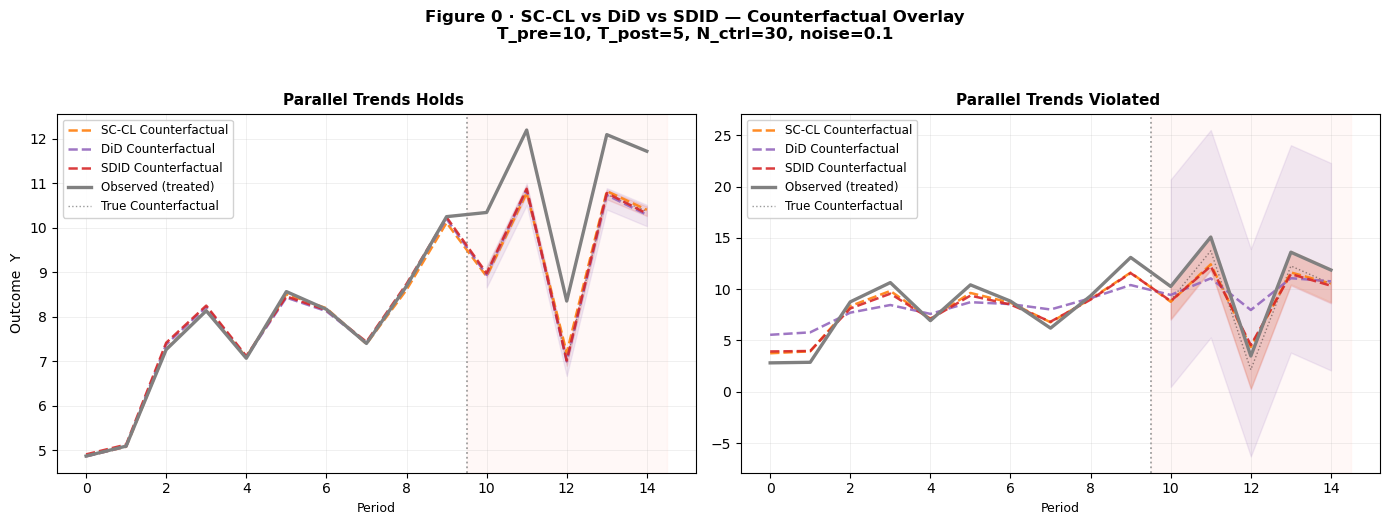

In [7]:
# Build unified plot data for both scenarios (reused by Figures 1 and 2)
pd0 = build_plot_data(df0, r0_adh, r0_di, r0_cl, r0_did_cf, r0_sdid, r0_sdid_inf, T_PRE)
pd1 = build_plot_data(df1, r1_adh, r1_di, r1_cl, r1_did_cf, r1_sdid, r1_sdid_inf, T_PRE)

# ── Figure 0: SC-CL vs DiD vs SDID — counterfactual overlay ───────────────

def draw_overlay(plot_data, true_att, sigma_label, ax):
    overlay_models = ['SC-CL', 'DiD', 'SDID']
    times  = plot_data['times']
    y_obs  = plot_data['y_treat']
    T_pre  = plot_data['T_pre']
    post_t = plot_data['post_t']

    ax.axvspan(T_pre - 0.5, max(times) + 0.5, alpha=0.04, color='tomato', zorder=0)
    ax.axvline(T_pre - 0.5, color='#888888', ls=':', lw=1.3, alpha=0.8, zorder=1)

    for mname in overlay_models:
        m   = plot_data['models'][mname]
        col = COLORS[mname]
        ax.fill_between(post_t,
                        [m['band_lo'][t] for t in post_t],
                        [m['band_hi'][t] for t in post_t],
                        color=col, alpha=0.12, zorder=2)
        cf_vals = [float(m['cf'].loc[t]) if t in m['cf'].index else float('nan')
                   for t in times]
        ax.plot(times, cf_vals, color=col, lw=1.8, ls='--', alpha=0.90, zorder=5,
                label=f'{mname} Counterfactual')

    ax.plot(times, [float(y_obs.loc[t]) for t in times],
            color='grey', lw=2.4, zorder=6, label='Observed (treated)')

    ax.plot(post_t, [float(y_obs.loc[t]) - true_att for t in post_t],
            color='black', ls=':', lw=1.0, alpha=0.40,
            label=f'True Counterfactual')

    ax.set_title(sigma_label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Period', fontsize=9)
    ax.grid(True, alpha=0.22, lw=0.6)
    ax.legend(fontsize=8.5, loc='upper left', framealpha=0.88)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle(
    'Figure 0 \u00b7 SC-CL vs DiD vs SDID \u2014 Counterfactual Overlay\n'
    f'T_pre={T_PRE}, T_post={T_POST}, N_ctrl={N_CTRL}, noise={NOISE_SD}',
    fontsize=12, fontweight='bold', y=1.04)

draw_overlay(pd0, att0, 'Parallel Trends Holds ', axes[0])
draw_overlay(pd1, att1, 'Parallel Trends Violated ', axes[1])
axes[0].set_ylabel('Outcome  Y', fontsize=10)
plt.tight_layout()
plt.show()


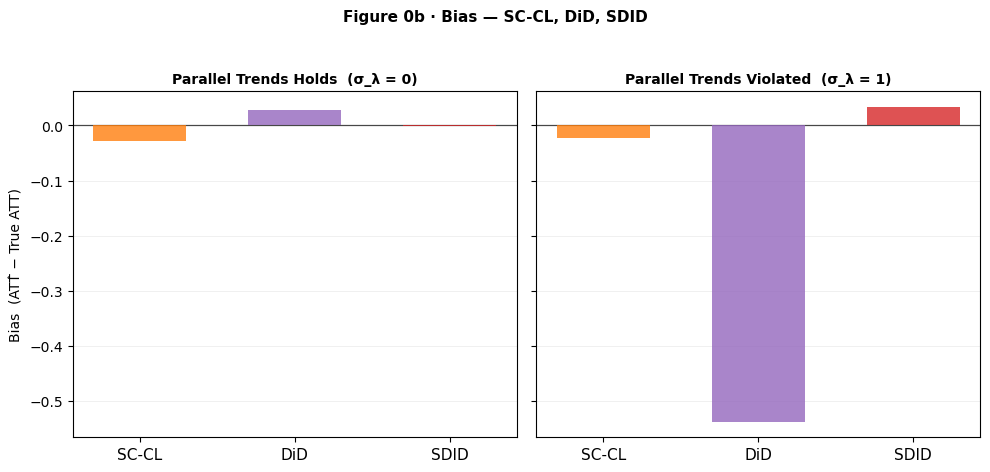

In [19]:
# ── Figure 0b: Bias chart — SC-CL, DiD, SDID (both scenarios) ─────────────

_models_bias = ['SC-CL', 'DiD', 'SDID']
_colors_bias = [COLORS[m] for m in _models_bias]
_x = np.arange(len(_models_bias))
_w = 0.30

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
fig.suptitle(
    'Figure 0b · Bias — SC-CL, DiD, SDID',
    # 'Bars = ATT̂ − True ATT  ·  Error bars = conformal 95% CI re-centred on bias',
    fontsize=11, fontweight='bold', y=1.04)

for ax, summary, scenario_label in [
        (axes[0], summary0, f'Parallel Trends Holds  (σ_λ = 0)'),
        (axes[1], summary1, f'Parallel Trends Violated  (σ_λ = 1)')]:

    biases  = [float(summary.loc[m, 'Bias'])   for m in _models_bias]
    # ci_lo   = [float(summary.loc[m, 'CI_lo'])  for m in _models_bias]
    # ci_hi   = [float(summary.loc[m, 'CI_hi'])  for m in _models_bias]
    true_att = float(summary['True_ATT'].iloc[0])

    # # Re-centre CI around bias: (ci_lo - true_att, ci_hi - true_att)
    # err_lo  = [b - (lo - true_att) for b, lo in zip(biases, ci_lo)]   # = att - ci_lo
    # err_hi  = [(hi - true_att) - b for b, hi in zip(biases, ci_hi)]   # = ci_hi - att

    bars = ax.bar(_x, biases, _w * 2, color=_colors_bias, alpha=0.80, zorder=3)
    # ax.errorbar(_x, biases,
    #             yerr=[err_lo, err_hi],
    #             fmt='none', color='#222222', capsize=5, lw=1.4, zorder=4)

    # ax.legend(_models_bias, fontsize=9, loc='upper left', framealpha=0.85)
    ax.axhline(0, color='black', lw=0.9, alpha=0.7)
    ax.set_xticks(_x)
    ax.set_xticklabels(_models_bias, fontsize=11)
    ax.set_title(scenario_label, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.22, lw=0.6, axis='y')

axes[0].set_ylabel('Bias  (ATT̂ − True ATT)', fontsize=10)
plt.tight_layout()
plt.show()

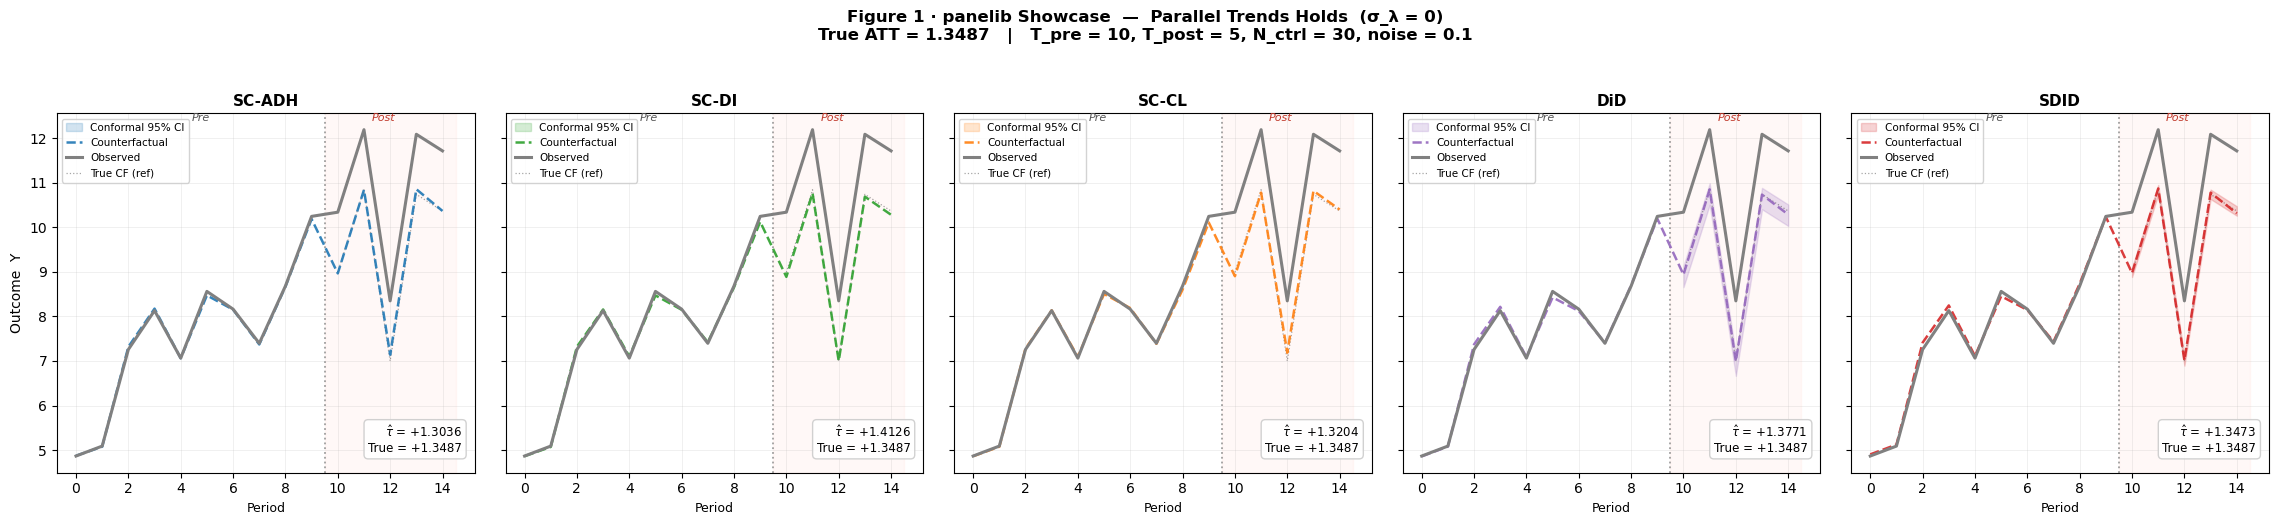

In [9]:
# ── Figure 1: Parallel Trends Holds (σ_λ = 0) ─────────────────────────────
pd0 = build_plot_data(
    df0, r0_adh, r0_di, r0_cl, r0_did_cf, r0_sdid, r0_sdid_inf, T_PRE)

draw_showcase(pd0, att0,
              sigma_label='Parallel Trends Holds  (σ_λ = 0)',
              fignum=1)

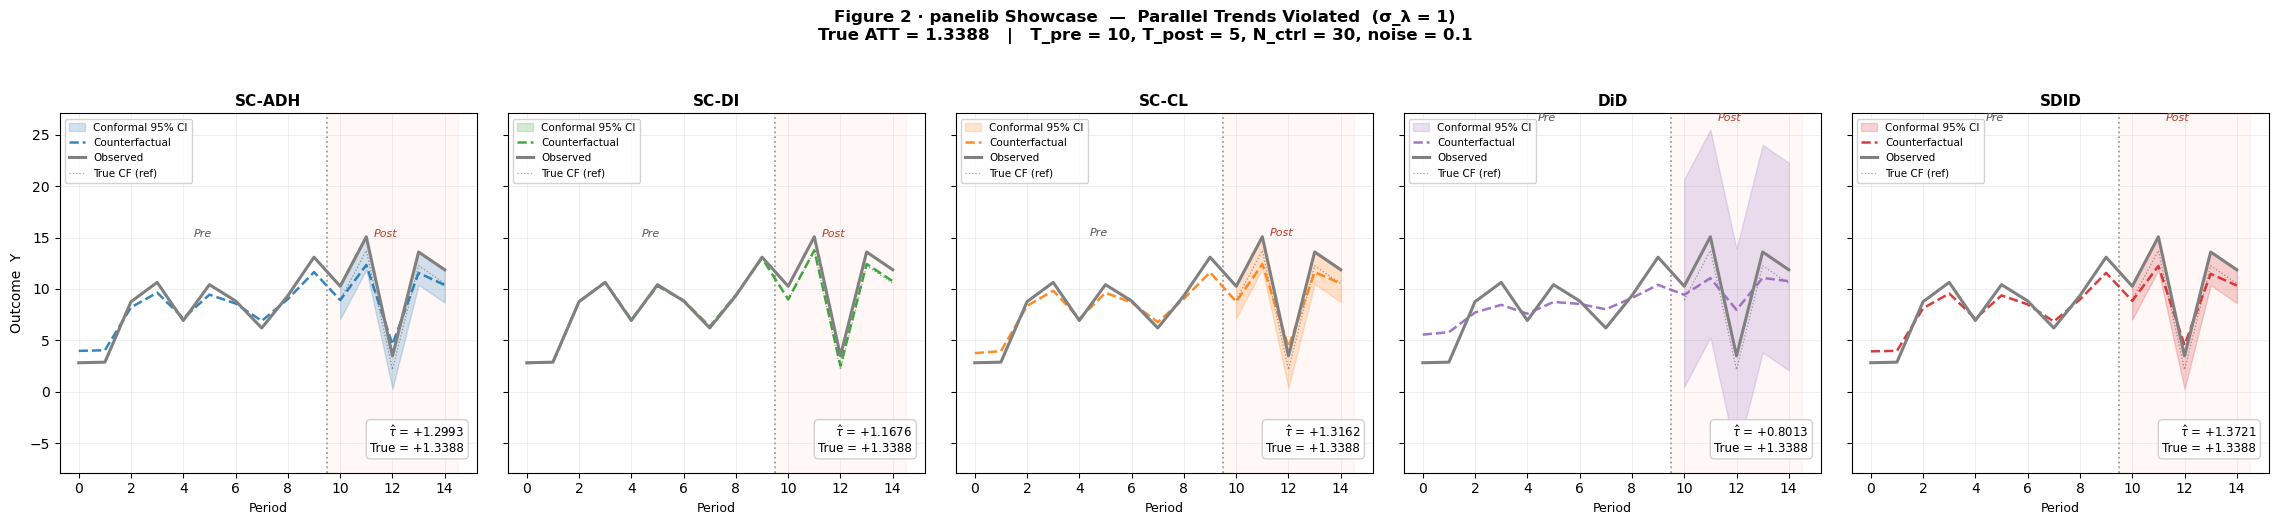

In [10]:
# ── Figure 2: Parallel Trends Violated (σ_λ = 1) ────────────────────────
pd1 = build_plot_data(
    df1, r1_adh, r1_di, r1_cl, r1_did_cf, r1_sdid, r1_sdid_inf, T_PRE)

draw_showcase(pd1, att1,
              sigma_label='Parallel Trends Violated  (σ_λ = 1)',
              fignum=2)

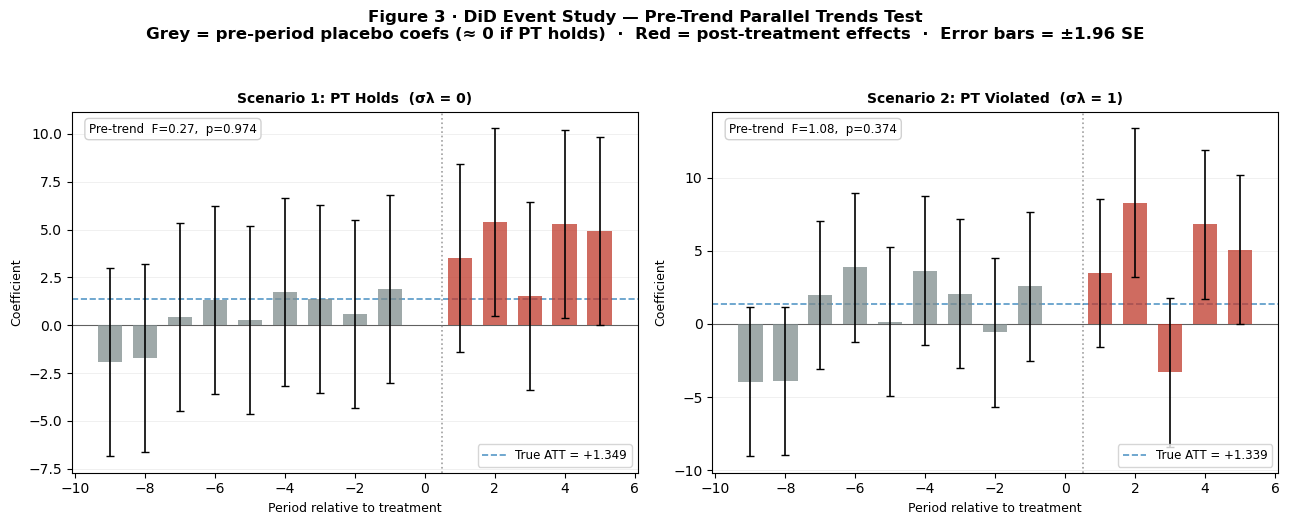

In [11]:
# ── Figure 3: DiD Event Study — parallel trends test ──────────────────────

def draw_event_study(r_did, true_att, T_pre, ax, title):
    es  = r_did['event_study'].copy()
    pre = es[es['pre_event'] == 1].copy()
    pst = es[es['pre_event'] == 0].copy()

    hold_out    = T_pre - 1
    pre['rel_t'] = pre['time_period'].astype(int) - hold_out
    pst['rel_t'] = pst['time_period'].astype(int) - hold_out

    all_es = pd.concat([pre, pst]).sort_values('rel_t')
    bar_colors = ['#c0392b' if r > 0 else '#7f8c8d' for r in all_es['rel_t']]

    ax.bar(all_es['rel_t'], all_es['coef_'],
           color=bar_colors, alpha=0.75, zorder=3, width=0.7)
    ax.errorbar(all_es['rel_t'], all_es['coef_'],
                yerr=1.96 * all_es['se_'],
                fmt='none', color='black', capsize=3, lw=1.2, zorder=4)

    ax.axhline(0, color='black', lw=0.8, alpha=0.6)
    ax.axvline(0.5, color='#888888', ls=':', lw=1.2, alpha=0.8)

    f_stat = float(pre['FJointStat'].iloc[0])
    f_pv   = float(pre['FJointPValue'].iloc[0])
    ax.text(0.03, 0.97,
            f'Pre-trend  F={f_stat:.2f},  p={f_pv:.3f}',
            transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#cccccc', alpha=0.9))

    ax.axhline(true_att, color='#1f77b4', ls='--', lw=1.2, alpha=0.75,
               label=f'True ATT = {true_att:+.3f}')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Period relative to treatment', fontsize=9)
    ax.set_ylabel('Coefficient', fontsize=9)
    ax.grid(True, alpha=0.22, lw=0.6, axis='y')
    ax.legend(fontsize=8.5, loc='lower right')


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Figure 3 \u00b7 DiD Event Study \u2014 Pre-Trend Parallel Trends Test\n'
    'Grey = pre-period placebo coefs (\u2248 0 if PT holds)  \u00b7  '
    'Red = post-treatment effects  \u00b7  Error bars = \u00b11.96 SE',
    fontsize=12, fontweight='bold', y=1.04)

draw_event_study(r0_did, att0, T_PRE, axes[0],
                 'Scenario 1: PT Holds  (\u03c3\u03bb = 0)')
draw_event_study(r1_did, att1, T_PRE, axes[1],
                 'Scenario 2: PT Violated  (\u03c3\u03bb = 1)')
plt.tight_layout()
plt.show()


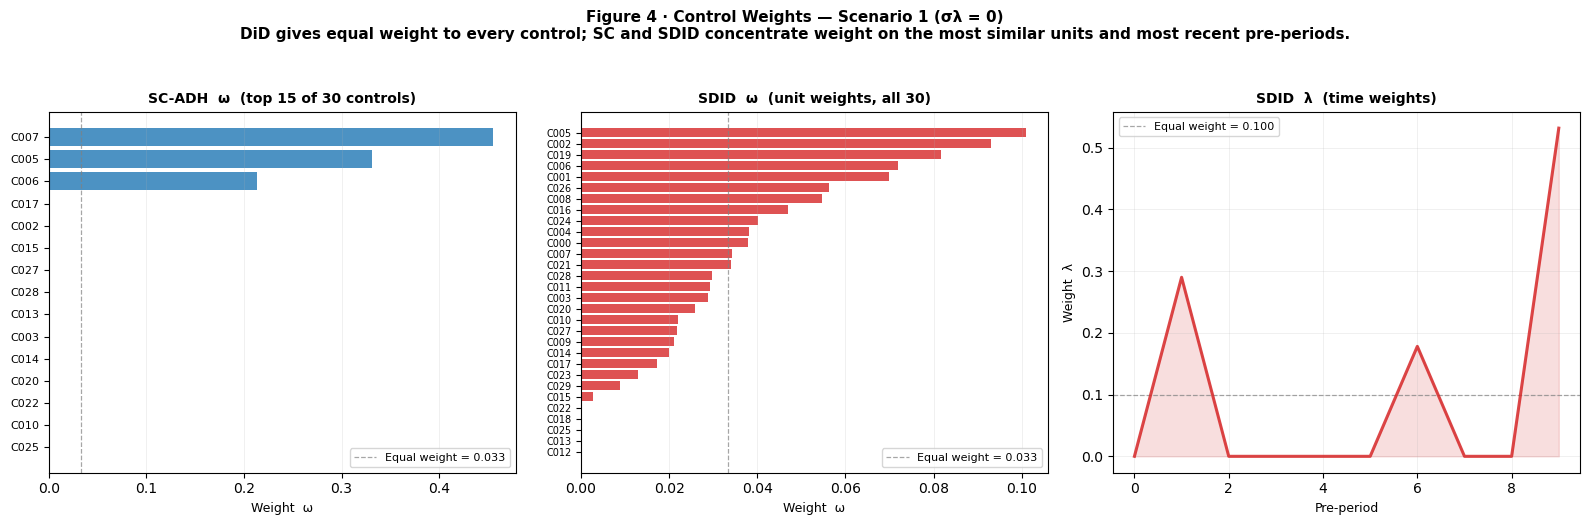

In [12]:
# ── Figure 4: Control weights — SC-ADH omega and SDID omega + lambda ──────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Figure 4 \u00b7 Control Weights \u2014 Scenario 1 (\u03c3\u03bb = 0)\n'
    'DiD gives equal weight to every control; SC and SDID concentrate weight '
    'on the most similar units and most recent pre-periods.',
    fontsize=11, fontweight='bold', y=1.04)

# Panel A: SC-ADH unit weights
ax = axes[0]
ctrl_ids  = sorted(df0.loc[df0['treated'] == 0, 'unit_id'].unique())
omega_adh = r0_adh['sc_est']['omega'].flatten()
omega_s   = pd.Series(omega_adh, index=ctrl_ids).sort_values(ascending=False)
top15     = omega_s.head(15)
ax.barh(range(len(top15)), top15.values[::-1], color='#1f77b4', alpha=0.8)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index[::-1], fontsize=8)
ax.set_xlabel('Weight  \u03c9', fontsize=9)
ax.set_title('SC-ADH  \u03c9  (top 15 of 30 controls)', fontsize=10, fontweight='bold')
equal_w = 1 / len(ctrl_ids)
ax.axvline(equal_w, color='grey', ls='--', lw=0.9, alpha=0.7,
           label=f'Equal weight = {equal_w:.3f}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.22, lw=0.6, axis='x')

# Panel B: SDID unit weights
ax = axes[1]
omega_sdid = r0_sdid['omega_weights'].sort_values('omega', ascending=False)
ax.barh(range(len(omega_sdid)), omega_sdid['omega'].values[::-1],
        color='#d62728', alpha=0.8)
ax.set_yticks(range(len(omega_sdid)))
ax.set_yticklabels(omega_sdid.index[::-1], fontsize=7)
ax.set_xlabel('Weight  \u03c9', fontsize=9)
ax.set_title('SDID  \u03c9  (unit weights, all 30)', fontsize=10, fontweight='bold')
equal_sdid = 1 / len(omega_sdid)
ax.axvline(equal_sdid, color='grey', ls='--', lw=0.9, alpha=0.7,
           label=f'Equal weight = {equal_sdid:.3f}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.22, lw=0.6, axis='x')

# Panel C: SDID time weights
ax = axes[2]
lam      = r0_sdid['lambda_weights']
equal_lam = 1 / len(lam)
ax.plot(lam.index, lam['lambda'], color='#d62728', lw=2.2, alpha=0.85, zorder=3)
ax.fill_between(lam.index, lam['lambda'], alpha=0.15, color='#d62728')
ax.axhline(equal_lam, color='grey', ls='--', lw=0.9, alpha=0.7,
           label=f'Equal weight = {equal_lam:.3f}')
ax.set_xlabel('Pre-period', fontsize=9)
ax.set_ylabel('Weight  \u03bb', fontsize=9)
ax.set_title('SDID  \u03bb  (time weights)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.22, lw=0.6)

plt.tight_layout()
plt.show()


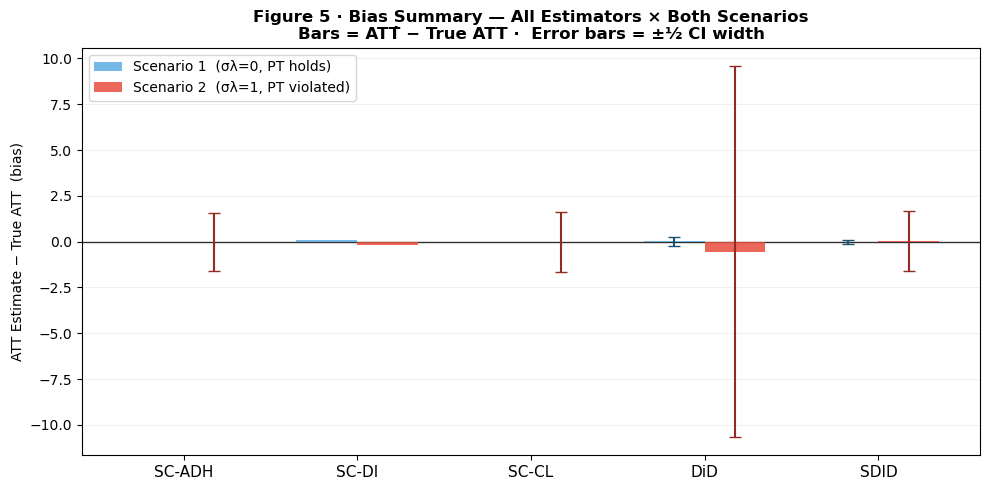

In [13]:
# ── Figure 5: Bias summary — all estimators × both scenarios ──────────────

models = ['SC-ADH', 'SC-DI', 'SC-CL', 'DiD', 'SDID']
bias0  = summary0['Bias'].reindex(models).values
bias1  = summary1['Bias'].reindex(models).values
ci_hw0 = summary0['CI_width'].reindex(models).values / 2
ci_hw1 = summary1['CI_width'].reindex(models).values / 2

x     = np.arange(len(models))
w     = 0.35
fig, ax = plt.subplots(figsize=(10, 5))

bars0 = ax.bar(x - w/2, bias0, w,
               label='Scenario 1  (\u03c3\u03bb=0, PT holds)',
               color='#5dade2', alpha=0.85, zorder=3)
bars1 = ax.bar(x + w/2, bias1, w,
               label='Scenario 2  (\u03c3\u03bb=1, PT violated)',
               color='#e74c3c', alpha=0.85, zorder=3)
ax.errorbar(x - w/2, bias0, yerr=ci_hw0,
            fmt='none', color='#1a5276', capsize=4, lw=1.5, zorder=4)
ax.errorbar(x + w/2, bias1, yerr=ci_hw1,
            fmt='none', color='#922b21', capsize=4, lw=1.5, zorder=4)

ax.axhline(0, color='black', lw=1.0, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('ATT Estimate \u2212 True ATT  (bias)', fontsize=10)
ax.set_title(
    'Figure 5 \u00b7 Bias Summary \u2014 All Estimators \u00d7 Both Scenarios\n'
    'Bars = ATT\u0302 \u2212 True ATT \u00b7  Error bars = \u00b1\u00bd CI width',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.22, lw=0.6, axis='y')
plt.tight_layout()
plt.show()
